In [1]:
import os
import sys

sys.path.append(os.path.join(os.getcwd(), "src"))

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_distances

from datasets import Dataset

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

dataset_key = "netbeans_pretrain_10"
run_name = "bge-base-netbeans_10_class_new_triplet"
generate_dataset = False
batch_size = 16
eval_size = 1000
num_frames = 10
num_train_pairs = 5
num_test_pairs = 1
# trim_length = 0
frame_freq = {}

test_dataset = Dataset.load_from_disk(f"datasets/{dataset_key}_eval")
model_before = SentenceTransformer("BAAI/bge-base-en")
model_after = SentenceTransformer(f"models/{run_name}/final")

print(f"Model sequence length: {model_before.max_seq_length}")

# Find model size in CUDA
print(f"Model size: {torch.cuda.memory_allocated() / 1024 ** 3:.2f} GB")

Using device: cuda
Model sequence length: 512
Model size: 1.64 GB


In [31]:
num_samples = 1000
metric = "cosine"

samples = test_dataset.select(range(num_samples))

anchor_positive_distances_before = []
anchor_negative_distances_before = []
anchor_positive_distances_after = []
anchor_negative_distances_after = []

# Compute distances for each triplet
for sample in samples:
    anchor, positive, negative = (
        sample["anchor"],
        sample["positive"],
        sample["negative"],
    )

    # Embeddings before training
    emb_anchor_before = model_before.encode(anchor)
    emb_positive_before = model_before.encode(positive)
    emb_negative_before = model_before.encode(negative)

    # Embeddings after training
    emb_anchor_after = model_after.encode(anchor)
    emb_positive_after = model_after.encode(positive)
    emb_negative_after = model_after.encode(negative)

    # Compute distances
    if metric == "cosine":
        anchor_positive_distances_before.append(
            cosine_distances([emb_anchor_before], [emb_positive_before])[0][0]
        )
        anchor_negative_distances_before.append(
            cosine_distances([emb_anchor_before], [emb_negative_before])[0][0]
        )
        anchor_positive_distances_after.append(
            cosine_distances([emb_anchor_after], [emb_positive_after])[0][0]
        )
        anchor_negative_distances_after.append(
            cosine_distances([emb_anchor_after], [emb_negative_after])[0][0]
        )
    elif metric == "euclidean":
        anchor_positive_distances_before.append(
            np.linalg.norm(emb_anchor_before - emb_positive_before)
        )
        anchor_negative_distances_before.append(
            np.linalg.norm(emb_anchor_before - emb_negative_before)
        )
        anchor_positive_distances_after.append(
            np.linalg.norm(emb_anchor_after - emb_positive_after)
        )
        anchor_negative_distances_after.append(
            np.linalg.norm(emb_anchor_after - emb_negative_after)
        )

In [16]:
from matplotlib import font_manager

font_path = "/home/mdafifal.mamun/research/S3M/src/times.ttf"  # Adjust based on your OS

font_manager.fontManager.addfont(font_path)

print(font_manager.fontManager.ttflist)

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"

[FontEntry(fname='/home/mdafifal.mamun/miniconda3/envs/tracesim/lib/python3.8/site-packages/matplotlib/mpl-data/fonts/ttf/STIXNonUniIta.ttf', name='STIXNonUnicode', style='italic', variant='normal', weight=400, stretch='normal', size='scalable'), FontEntry(fname='/home/mdafifal.mamun/miniconda3/envs/tracesim/lib/python3.8/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSansMono-BoldOblique.ttf', name='DejaVu Sans Mono', style='oblique', variant='normal', weight=700, stretch='normal', size='scalable'), FontEntry(fname='/home/mdafifal.mamun/miniconda3/envs/tracesim/lib/python3.8/site-packages/matplotlib/mpl-data/fonts/ttf/cmtt10.ttf', name='cmtt10', style='normal', variant='normal', weight=400, stretch='normal', size='scalable'), FontEntry(fname='/home/mdafifal.mamun/miniconda3/envs/tracesim/lib/python3.8/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-Italic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=400, stretch='normal', size='scalable'), FontEntry(f

In [41]:
def visualize_distances_before_after():
    # Create a vertically stacked layout
    fig, axes = plt.subplots(2, 1, figsize=(6, 7), sharex=True)

    pos_colors = "royalblue"
    neg_colors = "orangered"
    anchor_color = "lightseagreen"

    # Plot distances before training
    axes[0].scatter(
        range(num_samples),
        anchor_positive_distances_before,
        color=pos_colors,
        label="Anchor-Positive",
        alpha=0.7,
        edgecolors="black",
    )
    axes[0].scatter(
        range(num_samples),
        anchor_negative_distances_before,
        color=neg_colors,
        label="Anchor-Negative",
        alpha=0.7,
        edgecolors="black",
    )
    axes[0].axhline(y=0, color=anchor_color, linestyle='--', linewidth=3, label='Anchor')
    axes[0].set_title("Before Embedding Model Training", fontsize=12)
    axes[0].set_ylabel(f"{metric.capitalize()} Distance", fontsize=12)
    axes[0].grid(True, linestyle="--", alpha=0.6)
    axes[0].set_ylim(0, 1) 

    # Plot distances after training
    axes[1].scatter(
        range(num_samples),
        anchor_positive_distances_after,
        color=pos_colors,
        label="Anchor-Positive",
        alpha=0.7,
        edgecolors="black",
    )
    axes[1].scatter(
        range(num_samples),
        anchor_negative_distances_after,
        color=neg_colors,
        label="Anchor-Negative",
        alpha=0.7,
        edgecolors="black",
    )
    axes[1].axhline(y=0, color=anchor_color, linestyle='--', linewidth=3, label='Anchor')
    axes[1].set_title("After Embedding Model Training", fontsize=12)
    axes[1].set_xlabel("Sample Index", fontsize=12)
    axes[1].set_ylabel(f"{metric.capitalize()} Distance", fontsize=12)
    axes[1].grid(True, linestyle="--", alpha=0.6)
    axes[1].set_ylim(0, 1) 

    # Create a single legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=12, frameon=True)

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.savefig("distance_plot_improved.png", dpi=300)
    # Save as PDF
    plt.savefig("distance_plot_improved.pdf", dpi=300, bbox_inches='tight', pad_inches=0)
    plt.show()

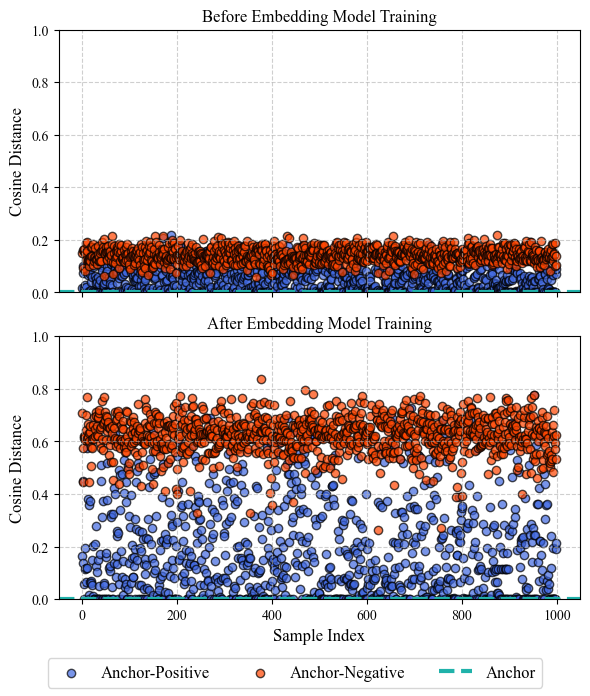

In [42]:
visualize_distances_before_after()

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import random

def generate_tsne_plot(test_dataset, model, num_samples=10, random_seed=42):
    # Extract the first 'num_samples' test samples randomly
    random.seed(random_seed)
    random_indices = random.sample(range(len(test_dataset)), num_samples)
    raw_samples = test_dataset.select(random_indices)
    print("Before:", len(raw_samples))

    samples = [sample for sample in raw_samples if sample["anchor"] != sample["positive"]]
    print("After:", len(samples))

    # Prepare lists to hold embeddings and labels for anchor, positive, and negative samples
    embeddings = []
    labels = []  # 0 for anchor, 1 for positive, 2 for negative
    pairs = []  # To store connections for anchors to positive and negative points
    colors = ["blue", "green", "red"]  # Colors for anchor, positive, negative

    for i in range(len(samples)):
        # Get anchor, positive, and negative sentences
        anchor_sentence = samples[i]["anchor"]
        positive_sentence = samples[i]["positive"]
        negative_sentence = samples[i]["negative"]

        # Get embeddings for anchor, positive, and negative
        anchor_embedding = model.encode([anchor_sentence])[0]
        positive_embedding = model.encode([positive_sentence])[0]
        negative_embedding = model.encode([negative_sentence])[0]

        # Append embeddings and labels
        embeddings.append(anchor_embedding)
        labels.append(0)  # Anchor

        embeddings.append(positive_embedding)
        labels.append(1)  # Positive

        embeddings.append(negative_embedding)
        labels.append(2)  # Negative

        # Store pairs (anchor, positive) and (anchor, negative)
        pairs.append((len(embeddings) - 3, len(embeddings) - 2))  # (anchor, positive)
        pairs.append((len(embeddings) - 3, len(embeddings) - 1))  # (anchor, negative)

    embeddings = np.array(embeddings)
    labels = np.array(labels)

    # Apply t-SNE to reduce dimensionality to 2D for visualization
    tsne = TSNE(n_components=2, random_state=42, perplexity=len(samples))
    tsne_results = tsne.fit_transform(embeddings)

    # Plot the t-SNE results
    plt.figure(figsize=(6, 4))

    # Plot each type of sample with different colors
    for i, color in enumerate(colors):
        plt.scatter(
            tsne_results[labels == i, 0],
            tsne_results[labels == i, 1],
            c=color,
            label=["Anchor", "Positive", "Negative"][i],
            alpha=0.7,
        )

    # Add connections (lines) for each anchor to its positive and negative samples
    for anchor_idx, target_idx in pairs:
        plt.plot(
            [tsne_results[anchor_idx, 0], tsne_results[target_idx, 0]],
            [tsne_results[anchor_idx, 1], tsne_results[target_idx, 1]],
            color="gray",
            alpha=0.5,
            linestyle="--",
        )

    # Add sequential labels only to anchor points
    anchor_indices = np.where(labels == 0)[0]  # Indices of anchor points
    for i, idx in enumerate(anchor_indices):  # Sequential numbering for anchors only
        plt.text(
            tsne_results[idx, 0] + 0.5,
            tsne_results[idx, 1] + 0.5,
            str(i + 1),  # Start numbering from 1
            fontsize=9,
            color="black",
            weight="bold",
        )

    plt.title("t-SNE Visualization of Anchor, Positive, and Negative Samples")
    plt.xlabel("t-SNE Component 1")
    plt.ylabel("t-SNE Component 2")
    plt.legend()
    plt.savefig("tsne_plot_with_connections_2.png")
    plt.show()


Before: 7
After: 6


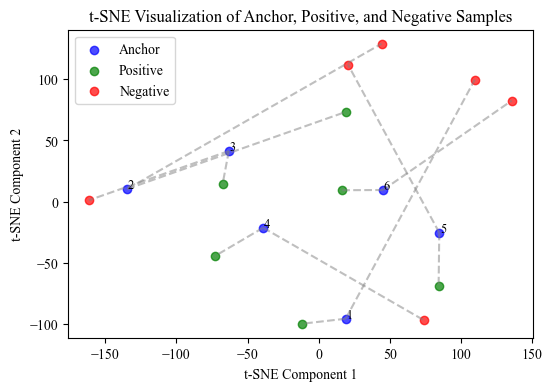

Before: 7
After: 6


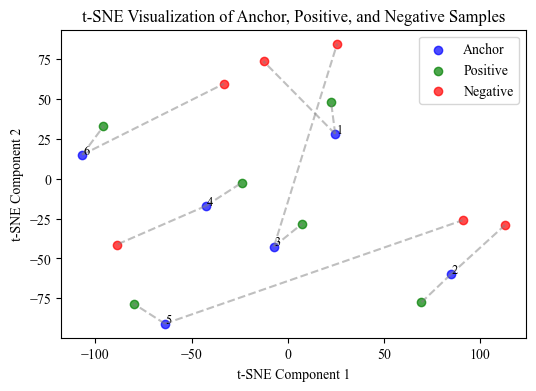

In [47]:
# n_s = 5
# seed = 2252

n_s = 7
seed = 999999
generate_tsne_plot(test_dataset, model_before, num_samples=n_s, random_seed=seed)
generate_tsne_plot(test_dataset, model_after, num_samples=n_s, random_seed=seed)

In [ ]:
generate_tsne_plot(test_dataset, model, num_samples=n_s, random_seed=seed)
generate_tsne_plot(test_dataset, model_after, num_samples=n_s, random_seed=seed)

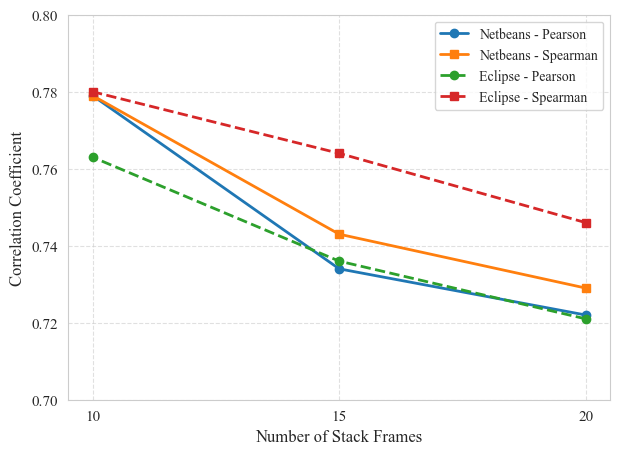

In [17]:
import matplotlib.pyplot as plt

# Data
frames = [20, 15, 10]
netbeans_pearson = [0.722, 0.734, 0.779]
netbeans_spearman = [0.729, 0.743, 0.779]
eclipse_pearson = [0.721, 0.736, 0.763]
eclipse_spearman = [0.746, 0.764, 0.780]

# Plot
plt.figure(figsize=(7, 5))
plt.plot(frames, netbeans_pearson, marker='o', linestyle='-', linewidth=2, markersize=6, label='Netbeans - Pearson')
plt.plot(frames, netbeans_spearman, marker='s', linestyle='-', linewidth=2, markersize=6, label='Netbeans - Spearman')
plt.plot(frames, eclipse_pearson, marker='o', linestyle='--', linewidth=2, markersize=6, label='Eclipse - Pearson')
plt.plot(frames, eclipse_spearman, marker='s', linestyle='--', linewidth=2, markersize=6, label='Eclipse - Spearman')

# Labels and legend
plt.xlabel('Number of Stack Frames', fontsize=12)
plt.ylabel('Correlation Coefficient', fontsize=12)
# plt.title('Embedding Similarity Metrics vs. Stack Frames', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(frames, fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0.7, 0.8)

# Show plot
plt.savefig("frames-vs-embeddings.pdf", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()


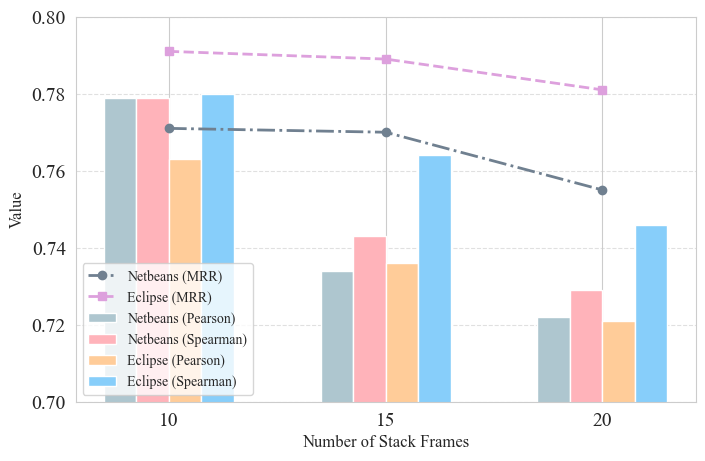

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Data
frames = [10, 15, 20]
netbeans_pearson = [0.779, 0.734, 0.722]
netbeans_spearman = [0.779, 0.743, 0.729]
eclipse_pearson = [0.763, 0.736, 0.721]
eclipse_spearman = [0.780, 0.764, 0.746]
nb_mrr = [0.771, 0.770, 0.755]
ec_mrr = [0.791, 0.789, 0.781]

# Bar width and positions
bar_width = 0.15
index = np.arange(len(frames))

# Light colors
colors = ['#AEC6CF', '#FFB3BA', '#FFCC99', 'lightskyblue']
mrr_colors = ['slategray', 'plum']

# Create figure and axis
plt.figure(figsize=(8, 5))

# Bars for correlation coefficients
plt.bar(index - 1.5 * bar_width, netbeans_pearson, bar_width, label='Netbeans (Pearson)', color=colors[0])
plt.bar(index - 0.5 * bar_width, netbeans_spearman, bar_width, label='Netbeans (Spearman)', color=colors[1])
plt.bar(index + 0.5 * bar_width, eclipse_pearson, bar_width, label='Eclipse (Pearson)', color=colors[2])
plt.bar(index + 1.5 * bar_width, eclipse_spearman, bar_width, label='Eclipse (Spearman)', color=colors[3])

# Overlay MRR as lines
plt.plot(index, nb_mrr, marker='o', linestyle='-.', color=mrr_colors[0], label='Netbeans (MRR)', linewidth=2)
plt.plot(index, ec_mrr, marker='s', linestyle='--', color=mrr_colors[1], label='Eclipse (MRR)', linewidth=2)

# Labels and legend
plt.xlabel('Number of Stack Frames', fontsize=12)
plt.ylabel('Value', fontsize=12)  # Single label for both metrics
plt.xticks(index, frames, fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0.7, 0.8)  # Unified scale
plt.legend(fontsize=10, loc='lower left')
plt.grid(True, linestyle='--', alpha=0.6, axis='y')

# Save and show
plt.savefig("frames-vs-embeddings-bar-chart-with-mrr.pdf", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()


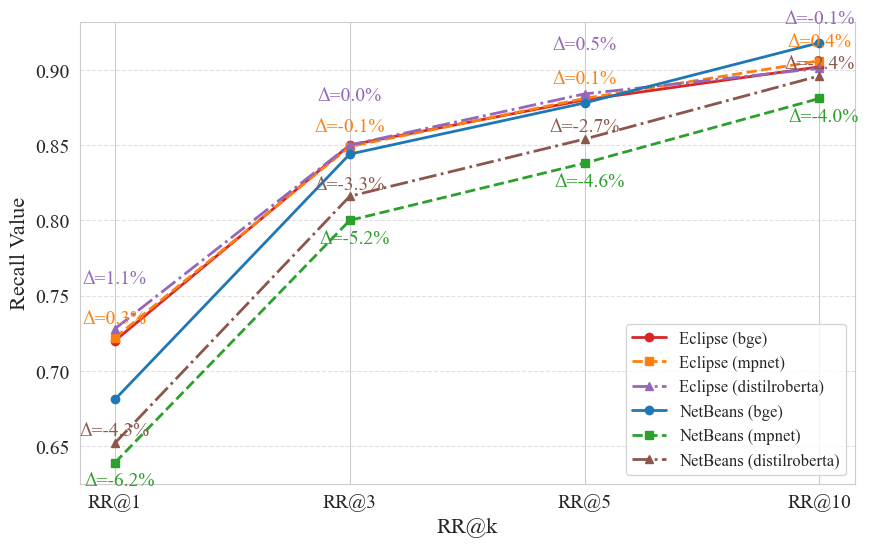

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Data
eclipse_mpnet_rr = np.array([0.722, 0.849, 0.881, 0.906])
eclipse_distilroberta_rr = np.array([0.728, 0.850, 0.884, 0.901])
eclipse_bge_rr = np.array([0.720, 0.850, 0.880, 0.902])

netbeans_mpnet_rr = np.array([0.639, 0.800, 0.838, 0.881])
netbeans_distilroberta_rr = np.array([0.652, 0.816, 0.854, 0.896])
netbeans_bge_rr = np.array([0.681, 0.844, 0.878, 0.918])

rr_labels = ["RR@1", "RR@3", "RR@5", "RR@10"]
x = np.arange(len(rr_labels))

# Compute Percentage Deltas (compared to bge)
delta_eclipse_mpnet = ((eclipse_mpnet_rr - eclipse_bge_rr) / eclipse_bge_rr) * 100
delta_eclipse_distilroberta = ((eclipse_distilroberta_rr - eclipse_bge_rr) / eclipse_bge_rr) * 100

delta_netbeans_mpnet = ((netbeans_mpnet_rr - netbeans_bge_rr) / netbeans_bge_rr) * 100
delta_netbeans_distilroberta = ((netbeans_distilroberta_rr - netbeans_bge_rr) / netbeans_bge_rr) * 100

# Plot
plt.figure(figsize=(10, 6))

# Eclipse Lines (Warm Colors)
plt.plot(x, eclipse_bge_rr, marker='o', linestyle='-', label='Eclipse (bge)', color='#D62728', linewidth=2)  # Red
plt.plot(x, eclipse_mpnet_rr, marker='s', linestyle='--', label='Eclipse (mpnet)', color='#FF7F0E', linewidth=2)  # Orange
plt.plot(x, eclipse_distilroberta_rr, marker='^', linestyle='-.', label='Eclipse (distilroberta)', color='#9467BD', linewidth=2)  # Purple

# NetBeans Lines (Cool Colors)
plt.plot(x, netbeans_bge_rr, marker='o', linestyle='-', label='NetBeans (bge)', color='#1F77B4', linewidth=2)  # Blue
plt.plot(x, netbeans_mpnet_rr, marker='s', linestyle='--', label='NetBeans (mpnet)', color='#2CA02C', linewidth=2)  # Green
plt.plot(x, netbeans_distilroberta_rr, marker='^', linestyle='-.', label='NetBeans (distilroberta)', color='#8C564B', linewidth=2)  # Brown

# Add Percentage Delta Annotations (Compared to BGE)
for i in range(len(rr_labels)):
    # Eclipse
    plt.text(x[i], eclipse_mpnet_rr[i] + 0.01, f"Δ={delta_eclipse_mpnet[i]:.1f}%", ha='center', fontsize=14, color='#FF7F0E')
    plt.text(x[i], eclipse_distilroberta_rr[i] + 0.03, f"Δ={delta_eclipse_distilroberta[i]:.1f}%", ha='center', fontsize=14, color='#9467BD')

    # NetBeans
    plt.text(x[i] + 0.02, netbeans_mpnet_rr[i] - 0.015, f"Δ={delta_netbeans_mpnet[i]:.1f}%", ha='center', fontsize=14, color='#2CA02C')
    plt.text(x[i], netbeans_distilroberta_rr[i] + 0.005, f"Δ={delta_netbeans_distilroberta[i]:.1f}%", ha='center', fontsize=14, color='#8C564B')

# Labels and title
plt.xticks(x, rr_labels)
plt.xlabel("RR@k", fontsize=16)
plt.ylabel("Recall Value", fontsize=16)
plt.legend(fontsize=12, loc="lower right")
plt.grid(axis='y', linestyle='dashed', alpha=0.6)

# Increase font size for ticks
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.savefig("rr-vs-embedding-models.pdf", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()


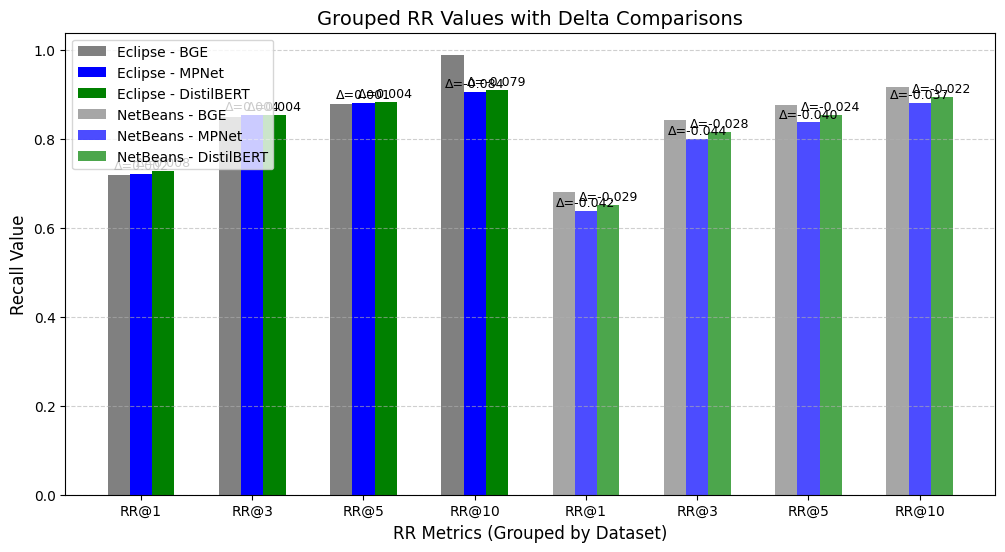

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Data
eclipse_mpnet_rr = np.array([0.722, 0.854, 0.881, 0.906])
eclipse_distilbert_rr = np.array([0.728, 0.854, 0.884, 0.911])
eclipse_bge_rr = np.array([0.720, 0.850, 0.880, 0.9902])

netbeans_mpnet_rr = np.array([0.639, 0.800, 0.838, 0.881])
netbeans_distilbert_rr = np.array([0.652, 0.816, 0.854, 0.896])
netbeans_bge_rr = np.array([0.681, 0.844, 0.878, 0.918])

rr_labels = ["RR@1", "RR@3", "RR@5", "RR@10"]
x = np.arange(len(rr_labels))  # Base x positions
bar_width = 0.2  # Width of each bar

# Compute Deltas (compared to BGE)
delta_eclipse_mpnet = eclipse_mpnet_rr - eclipse_bge_rr
delta_eclipse_distilbert = eclipse_distilbert_rr - eclipse_bge_rr

delta_netbeans_mpnet = netbeans_mpnet_rr - netbeans_bge_rr
delta_netbeans_distilbert = netbeans_distilbert_rr - netbeans_bge_rr

# Create figure
plt.figure(figsize=(12, 6))

# Eclipse Bars
plt.bar(x - bar_width, eclipse_bge_rr, width=bar_width, label="Eclipse - BGE", color="gray")
plt.bar(x, eclipse_mpnet_rr, width=bar_width, label="Eclipse - MPNet", color="blue")
plt.bar(x + bar_width, eclipse_distilbert_rr, width=bar_width, label="Eclipse - DistilBERT", color="green")

# NetBeans Bars (Shifted for grouping)
x_shifted = x + len(rr_labels)  # Shift NetBeans bars
plt.bar(x_shifted - bar_width, netbeans_bge_rr, width=bar_width, label="NetBeans - BGE", color="gray", alpha=0.7)
plt.bar(x_shifted, netbeans_mpnet_rr, width=bar_width, label="NetBeans - MPNet", color="blue", alpha=0.7)
plt.bar(x_shifted + bar_width, netbeans_distilbert_rr, width=bar_width, label="NetBeans - DistilBERT", color="green", alpha=0.7)

# Add Delta Annotations (Above MPNet & DistilBERT)
for i in range(len(rr_labels)):
    plt.text(x[i], eclipse_mpnet_rr[i] + 0.01, f"Δ={delta_eclipse_mpnet[i]:.3f}", ha='center', fontsize=9, color='black')
    plt.text(x[i] + bar_width, eclipse_distilbert_rr[i] + 0.01, f"Δ={delta_eclipse_distilbert[i]:.3f}", ha='center', fontsize=9, color='black')

    plt.text(x_shifted[i], netbeans_mpnet_rr[i] + 0.01, f"Δ={delta_netbeans_mpnet[i]:.3f}", ha='center', fontsize=9, color='black')
    plt.text(x_shifted[i] + bar_width, netbeans_distilbert_rr[i] + 0.01, f"Δ={delta_netbeans_distilbert[i]:.3f}", ha='center', fontsize=9, color='black')

# Labels and title
xticks = list(rr_labels) + list(rr_labels)  # Repeat for NetBeans
plt.xticks(np.concatenate([x, x_shifted]), xticks)  # Set x-ticks properly

plt.xlabel("RR Metrics (Grouped by Dataset)", fontsize=12)
plt.ylabel("Recall Value", fontsize=12)
plt.title("Grouped RR Values with Delta Comparisons", fontsize=14)
plt.legend()
plt.grid(axis='y', linestyle='dashed', alpha=0.6)

# Show plot
plt.show()
